Feed Forward Neural Network From Scratch for Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

X = np.linspace(-2*np.pi, 2*np.pi, 200).reshape(-1,1)
y = np.sin(X)

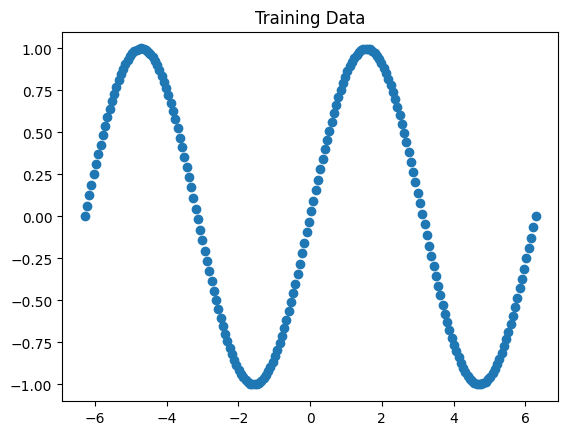

In [ ]:
plt.scatter(X, y)
plt.title("Training Data")
plt.show()

In [ ]:
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

In [ ]:
input_size = 1
hidden_size = 16
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

In [ ]:
def forward(X):

    A1 = X @ W1 + b1
    H1 = tanh(A1)

    A2 = H1 @ W2 + b2
    y_hat = A2

    cache = (A1, H1, A2, y_hat)

    return y_hat, cache


def mse_loss(y, y_hat):
    return np.mean((y - y_hat)**2)


def backward(X, y, y_hat, cache):

    global W1, b1, W2, b2

    A1, H1, A2, _ = cache

    N = X.shape[0]

    dA2 = (2/N) * (y_hat - y)

    dW2 = H1.T @ dA2
    db2 = np.sum(dA2, axis=0, keepdims=True)

    dH1 = dA2 @ W2.T

    dA1 = dH1 * tanh_derivative(A1)

    dW1 = X.T @ dA1
    db1 = np.sum(dA1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(dW1, db1, dW2, db2, lr):

    global W1, b1, W2, b2

    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

In [ ]:
epochs = 10000
lr = 0.01

losses = []

for epoch in range(epochs):

    y_hat, cache = forward(X)

    loss = mse_loss(y, y_hat)

    dW1, db1, dW2, db2 = backward(X, y, y_hat, cache)

    update_params(dW1, db1, dW2, db2, lr)

    losses.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.067556
Epoch 500, Loss: 0.067257
Epoch 1000, Loss: 0.066961
Epoch 1500, Loss: 0.066669
Epoch 2000, Loss: 0.066381
Epoch 2500, Loss: 0.066097
Epoch 3000, Loss: 0.065816
Epoch 3500, Loss: 0.065539
Epoch 4000, Loss: 0.065265
Epoch 4500, Loss: 0.064994
Epoch 5000, Loss: 0.064727
Epoch 5500, Loss: 0.064463
Epoch 6000, Loss: 0.064202
Epoch 6500, Loss: 0.063944
Epoch 7000, Loss: 0.063689
Epoch 7500, Loss: 0.063437
Epoch 8000, Loss: 0.063188
Epoch 8500, Loss: 0.062942
Epoch 9000, Loss: 0.062698
Epoch 9500, Loss: 0.062457


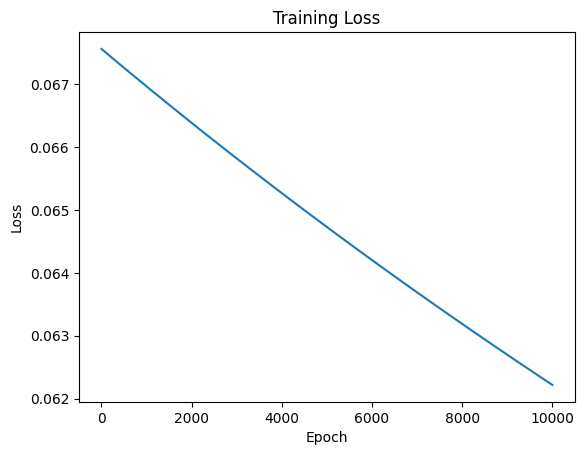

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

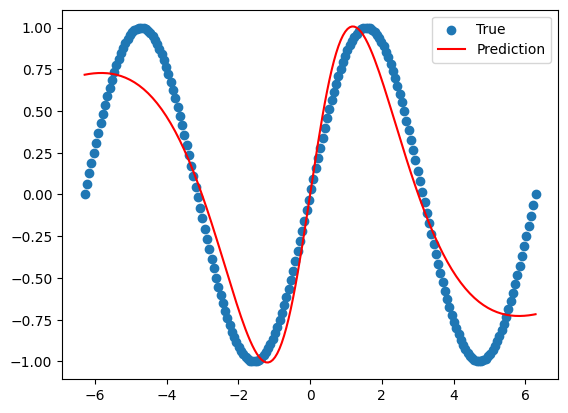

In [ ]:
y_pred, _ = forward(X)

plt.scatter(X, y, label="True")
plt.plot(X, y_pred, color='red', label="Prediction")

plt.legend()
plt.show()

Neural Network for Classification using Pytorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_features_shape):

        super().__init__()

        self.fc1 = nn.Linear(input_features_shape, 16)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):

        h1 = self.fc1(x)
        h1 = self.relu(h1)

        out = self.fc2(h1)

        return out

In [ ]:
input_features_shape = X_train.shape[1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = NeuralNetwork(input_features_shape).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)

Using device: cuda


In [ ]:
epochs = 200

for epoch in range(epochs):

    # Move data to device
    X_train_device = X_train.to(device)
    y_train_device = y_train.to(device)

    # Forward pass
    outputs = model(X_train_device)

    loss = criterion(outputs, y_train_device)

    # Backward pass
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 20 == 0:

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [20/200], Loss: 0.7404
Epoch [40/200], Loss: 0.4868
Epoch [60/200], Loss: 0.4757
Epoch [80/200], Loss: 0.4678
Epoch [100/200], Loss: 0.4386
Epoch [120/200], Loss: 0.4151
Epoch [140/200], Loss: 0.4389
Epoch [160/200], Loss: 0.3662
Epoch [180/200], Loss: 0.4166
Epoch [200/200], Loss: 0.4195


In [ ]:
with torch.no_grad():
    X_test_device = X_test.to(device)
    y_test_device = y_test.to(device)

    outputs = model(X_test_device)

    predictions = torch.argmax(outputs, dim=1)

    accuracy = (predictions == y_test_device).float().mean()

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8947


Batch vs Stochastic vs Mini-Batch GD


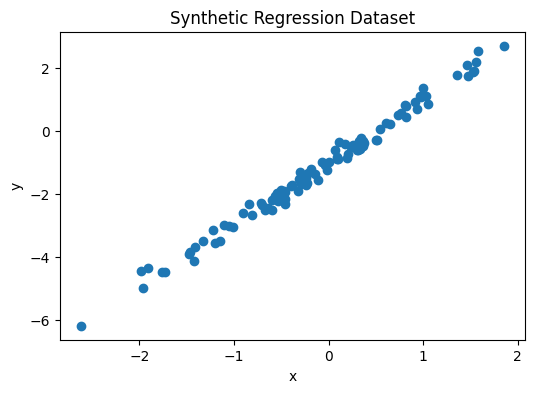

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100

X = np.random.randn(N, 1)

true_w = 2.0
true_b = -1.0

noise = 0.2 * np.random.randn(N, 1)

y = true_w * X + true_b + noise


plt.figure(figsize=(6,4))

plt.scatter(X, y)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Synthetic Regression Dataset")

plt.show()

In [ ]:
def compute_loss(w, b, X, y):

    y_pred = X * w + b

    loss = np.mean((y_pred - y) ** 2)

    return loss


def compute_gradients(w, b, X, y):

    N = X.shape[0]

    y_pred = X * w + b

    error = y_pred - y

    dw = (2 / N) * np.sum(error * X)

    db = (2 / N) * np.sum(error)

    return dw, db

In [ ]:
def run_gradient_descent(
    method="batch",
    lr=0.05,
    batch_size=16,
    epochs=50
):

    w = -3.0
    b = 3.0

    trajectory = [(w, b)]

    losses = [compute_loss(w, b, X, y)]

    N = X.shape[0]

    for epoch in range(epochs):

        if method == "batch":

            dw, db = compute_gradients(w, b, X, y)

            w -= lr * dw
            b -= lr * db

            trajectory.append((w, b))

            losses.append(compute_loss(w, b, X, y))

        elif method == "sgd":

            indices = np.random.permutation(N)

            for idx in indices:

                X_i = X[idx:idx+1]
                y_i = y[idx:idx+1]

                dw, db = compute_gradients(w, b, X_i, y_i)

                w -= lr * dw
                b -= lr * db

                trajectory.append((w, b))

                losses.append(compute_loss(w, b, X, y))

        elif method == "mini_batch":

            indices = np.random.permutation(N)

            for start_idx in range(0, N, batch_size):

                batch_indices = indices[start_idx:start_idx+batch_size]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                dw, db = compute_gradients(w, b, X_batch, y_batch)

                w -= lr * dw
                b -= lr * db

                trajectory.append((w, b))

                losses.append(compute_loss(w, b, X, y))

    return np.array(trajectory), np.array(losses)

In [ ]:
batch_traj, batch_losses = run_gradient_descent(
    method="batch",
    lr=0.1,
    epochs=40
)

sgd_traj, sgd_losses = run_gradient_descent(
    method="sgd",
    lr=0.01,
    epochs=20
)

mini_traj, mini_losses = run_gradient_descent(
    method="mini_batch",
    lr=0.05,
    batch_size=16,
    epochs=20
)

In [ ]:
w_values = np.linspace(-4, 4, 200)

b_values = np.linspace(-4, 4, 200)

W, B = np.meshgrid(w_values, b_values)

Z = np.zeros_like(W)

for i in range(W.shape[0]):

    for j in range(W.shape[1]):

        Z[i, j] = compute_loss(W[i, j], B[i, j], X, y)

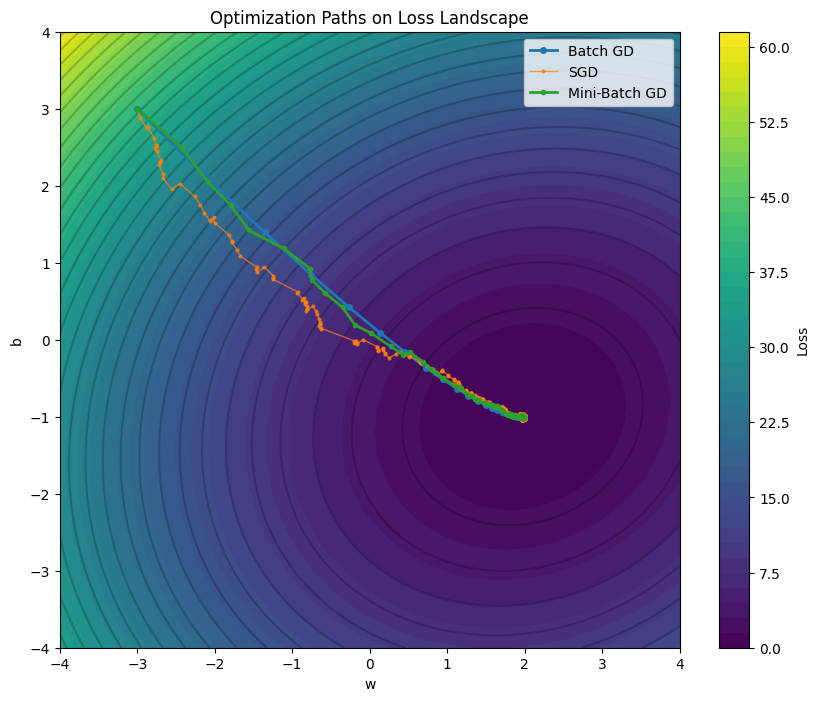

In [ ]:
plt.figure(figsize=(10,8))

contour = plt.contourf(
    W,
    B,
    Z,
    levels=50,
    cmap="viridis"
)

plt.colorbar(contour, label="Loss")

plt.contour(
    W,
    B,
    Z,
    levels=30,
    colors='black',
    alpha=0.2
)

# Batch GD
plt.plot(
    batch_traj[:,0],
    batch_traj[:,1],
    'o-',
    label="Batch GD",
    linewidth=2,
    markersize=4
)

# SGD
plt.plot(
    sgd_traj[:,0],
    sgd_traj[:,1],
    'o-',
    label="SGD",
    linewidth=1,
    markersize=2,
    alpha=0.7
)

# Mini-batch GD
plt.plot(
    mini_traj[:,0],
    mini_traj[:,1],
    'o-',
    label="Mini-Batch GD",
    linewidth=2,
    markersize=3
)

plt.xlabel("w")
plt.ylabel("b")

plt.title("Optimization Paths on Loss Landscape")

plt.legend()

plt.show()